# Aditya Rana
# I059
# B'Tech AI

# Task 1

In [11]:
import h2o
from h2o.automl import H2OAutoML

# 1. Initialize H2O cluster
h2o.init()

# 2. Load the dataset (Make sure data.csv is in your file directory)
df = h2o.import_file("data.csv")

# 3. Pre-processing
# Convert the target column 'Churn' to a factor (categorical) so H2O knows it's classification
df['Churn'] = df['Churn'].asfactor()

# 4. Define Predictors (X) and Target (y)
y = "Churn"
x = df.columns
x.remove(y)
if "customerID" in x:
    x.remove("customerID")

# 5. Split the data (Optional but recommended: 80% train, 20% test)
train, test = df.split_frame(ratios=[.8], seed=42)

# 6. Run H2O AutoML
aml = H2OAutoML(max_models=10, seed=42, project_name="Churn_Prediction")
aml.train(x=x, y=y, training_frame=train)

# 7. View the Leaderboard
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

# 8. Predict on Test Data (Optional)
preds = aml.predict(test)
print(preds.head())

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,18 mins 06 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,1 month and 27 days
H2O_cluster_name:,H2O_from_python_unknownUser_obiavh
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.147 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse       mse
StackedEnsemble_BestOfFamily_1_AutoML_1_20260121_145957  0.853217   0.408734  0.672868                0.227059  0.3643    0.132714
StackedEnsemble_AllModels_1_AutoML_1_20260121_145957     0.8528     0.409143  0.67148                 0.228519  0.364607  0.132938
GBM_1_AutoML_1_20260121_145957                           0.8525     0.409909  0.669921                0.229457  0.364949  0.133188
GLM_1_AutoML_1_20260121_145957                           0.848583   0.41518   0.659156                0.225862  0.367076  0.134744
GBM_2_AutoML_1_20260121_145957                           0.844829   0.419584  0.656498                0.233421  0.369426  0.136476
GBM_3_AutoML_1_20260121_

In [12]:
# 1. Initialize H2O
h2o.init()
df_iris = h2o.import_file("https://s3.amazonaws.com/h2o-public-test-data/smalldata/iris/iris_wheader.csv")

# 3. Define Predictors (X) and Target (y)
y = "class"
x = df_iris.columns
x.remove(y)

# 4. Split the data
train, test = df_iris.split_frame(ratios=[.8], seed=42)

# 5. Run H2O AutoML

aml_iris = H2OAutoML(max_models=5, seed=42, project_name="Iris_Classification")
aml_iris.train(x=x, y=y, training_frame=train)

# 6. View the Leaderboard
print("Leaderboard for Iris Dataset:")
print(aml_iris.leaderboard.head(rows=aml_iris.leaderboard.nrows))

# 7. Predict
preds = aml_iris.predict(test)
print(preds.head())

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,22 mins 19 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,1 month and 27 days
H2O_cluster_name:,H2O_from_python_unknownUser_obiavh
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.130 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███
15:04:18.753: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 121.0.

████████████████████████████████████████████████████████████| (done) 100%
Leaderboard for Task 1b (Iris Dataset):
model_id                                                   mean_per_class_error    logloss      rmse        mse
GLM_1_AutoML_2_20260121_150411                                        0.0337607  0.0658835  0.144692  0.0209358
StackedEnsemble_AllModels_1_AutoML_2_20260121_150411                  0.042094   0.0885568  0.162749  0.0264872
StackedEnsemble_BestOfFamily_1_AutoML_2_20260121_150411               0.042094   0.0861982  0.15963   0.0254816
XGBoost_2_AutoML_2_20260121_150411                                    0.050641   0.22214    0.225561  0.0508775
GBM_2_AutoML_2_20260121_150411                         

In [ ]:
import matplotlib.pyplot as plt

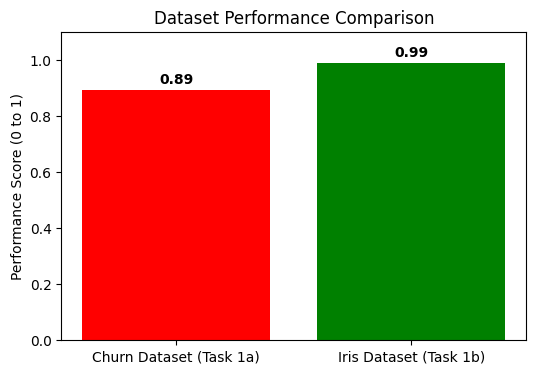

In [15]:

churn_score = aml.leader.auc()
iris_error = aml_iris.leader.mean_per_class_error()
iris_score = 1 - iris_error


datasets = ['Churn Dataset (Task 1a)', 'Iris Dataset (Task 1b)']
scores = [churn_score, iris_score]


plt.figure(figsize=(6, 4))
bars = plt.bar(datasets, scores, color=['red', 'green'])

plt.title("Dataset Performance Comparison")
plt.ylabel("Performance Score (0 to 1)")
plt.ylim(0, 1.1)


plt.text(0, churn_score + 0.02, f"{churn_score:.2f}", ha='center', fontweight='bold')
plt.text(1, iris_score + 0.02, f"{iris_score:.2f}", ha='center', fontweight='bold')

plt.show()

# Task 2

In [17]:
!pip install autokeras
import autokeras as ak
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# 1. Load MNIST Dataset (Downloads automatically)
print("Loading MNIST data...")
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Initialize Image Classifier
clf_mnist = ak.ImageClassifier(overwrite=True, max_trials=1, seed=42)

# 3. Search for the best model
print("Training AutoKeras on MNIST...")
clf_mnist.fit(x_train, y_train, epochs=1)

# 4. Evaluate
accuracy_mnist = clf_mnist.evaluate(x_test, y_test)[1]
print(f"MNIST Accuracy: {accuracy_mnist*100:.2f}%")

Trial 1 Complete [00h 02m 03s]
val_loss: 0.0627756118774414

Best val_loss So Far: 0.0627756118774414
Total elapsed time: 00h 02m 03s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 74ms/step - accuracy: 0.9078 - loss: 0.2924


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9824 - loss: 0.0608
MNIST Accuracy: 98.50%


In [18]:
from tensorflow.keras.datasets import fashion_mnist

# 1. Load Fashion MNIST Dataset (Downloads automatically)
print("Loading Fashion MNIST data...")
(x_train_f, y_train_f), (x_test_f, y_test_f) = fashion_mnist.load_data()

# 2. Initialize Image Classifier
clf_fashion = ak.ImageClassifier(overwrite=True, max_trials=1, seed=42)

# 3. Search for the best model
print("Training AutoKeras on Fashion MNIST...")
clf_fashion.fit(x_train_f, y_train_f, epochs=1)

# 4. Evaluate
accuracy_fashion = clf_fashion.evaluate(x_test_f, y_test_f)[1]
print(f"Fashion MNIST Accuracy: {accuracy_fashion*100:.2f}%")

Trial 1 Complete [00h 02m 11s]
val_loss: 0.32255974411964417

Best val_loss So Far: 0.32255974411964417
Total elapsed time: 00h 02m 11s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 75ms/step - accuracy: 0.8018 - loss: 0.5535


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8854 - loss: 0.3364
Fashion MNIST Accuracy: 88.16%


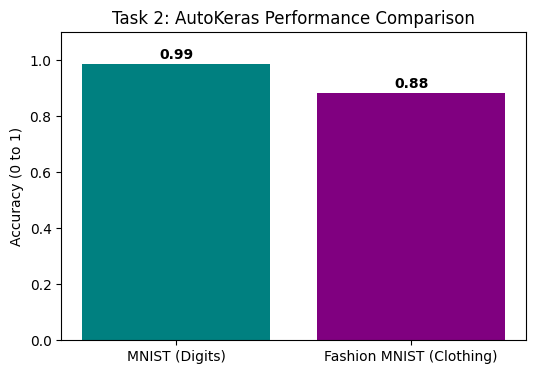

In [19]:
import matplotlib.pyplot as plt

# 1. Prepare Data
datasets = ['MNIST (Digits)', 'Fashion MNIST (Clothing)']
scores = [accuracy_mnist, accuracy_fashion]

# 2. Plot Simple Bar Chart
plt.figure(figsize=(6, 4))
bars = plt.bar(datasets, scores, color=['teal', 'purple'])

# 3. Formatting
plt.title("Task 2: AutoKeras Performance Comparison")
plt.ylabel("Accuracy (0 to 1)")
plt.ylim(0, 1.1)

# 4. Add scores on top of bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

# Zero Shot Assignment

# Phase 1

In [21]:
pip install torch torchvision pillow openai-clip


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
  Created wheel for openai-clip: filename=openai_clip-1.0.1-py3-none-any.whl size=1368605 sha256=90c3251020e525262f767bd3f06a72e7908fcb395cc0d52087b1651e736dd72a
  Stored in directory: /root/.cache/pip/wheels/ab/49/bc/c2342e8e14878210ba4825cf314a53f2570f6fb18b91fce3cf
Successfully built openai-clip


In [22]:
import torch
import clip
from PIL import Image

# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# Load and preprocess image
image_path = "/content/cat.jpg"   # <-- your image path
image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

# Define candidate labels (UNSEEN classes)
labels = [
    "a cat",
    "a dog",
    "a car",
    "a person",
    "a bicycle",
    "a tree"
]

# Convert text labels to text embeddings
text_tokens = clip.tokenize(labels).to(device)

# Zero-shot inference
with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text_tokens)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Compute similarity
    similarity = (image_features @ text_features.T).softmax(dim=-1)

# Get prediction
best_label_index = similarity.argmax().item()
predicted_label = labels[best_label_index]

# Output results
print("Predicted label:", predicted_label)
print("Confidence scores:")
for label, score in zip(labels, similarity[0]):
    print(f"{label}: {score.item():.4f}")


100%|███████████████████████████████████████| 338M/338M [00:08<00:00, 40.8MiB/s]


Predicted label: a cat
Confidence scores:
a cat: 0.1771
a dog: 0.1685
a car: 0.1641
a person: 0.1656
a bicycle: 0.1621
a tree: 0.1625


In [26]:
img = Image.open("/content/cat.jpg")
img.show()

# Phase 2

In [29]:
import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel

def zero_shot_classification(image_url, candidate_labels):
    """
    Performs zero-shot image classification using OpenAI's CLIP model.

    Args:
        image_url (str): URL of the image to classify.
        candidate_labels (list): A list of strings representing the classes.
    """

    # 1. Load the pre-trained model and processor
    # We use 'openai/clip-vit-base-patch32', a Vision Transformer (ViT) based model.
    # The processor handles the resizing/normalization of images and tokenization of text.
    print(f"Loading CLIP model...")
    model_id = "openai/clip-vit-base-patch32"
    model = CLIPModel.from_pretrained(model_id)
    processor = CLIPProcessor.from_pretrained(model_id)

    # 2. Load and preprocess the image
    # We stream the image from a URL to keep the example self-contained.
    print(f"Downloading image from: {image_url}")
    image = Image.open(requests.get(image_url, stream=True).raw)

    # 3. Process inputs
    # CLIP needs text descriptions to compare against the image.
    # It works best when the labels are framed as sentences (prompts).
    print("Processing inputs...")
    text_prompts = [f"a photo of a {label}" for label in candidate_labels]

    # The processor prepares both the image and the text tensors.
    # padding=True ensures all text sequences are the same length.
    inputs = processor(
        text=text_prompts,
        images=image,
        return_tensors="pt",
        padding=True
    )

    # 4. Inference (Forward Pass)
    # We disable gradient calculation because we are only doing inference, not training.
    print("Running inference...")
    with torch.no_grad():
        outputs = model(**inputs)

    # 5. Interpret Results
    # The model outputs 'logits_per_image', which are similarity scores between
    # the image and each text label.
    logits_per_image = outputs.logits_per_image

    # Apply Softmax to convert logits into probabilities that sum to 1.
    probs = logits_per_image.softmax(dim=1)

    # Convert tensor to a standard Python list for easier handling
    probs_list = probs.tolist()[0]

    # 6. Display Output
    print("\n--- Classification Results ---")
    # Zip the original labels with their probabilities and sort by highest probability
    results = sorted(zip(candidate_labels, probs_list), key=lambda x: x[1], reverse=True)

    for label, probability in results:
        print(f"{label}: {probability:.4f} ({probability*100:.2f}%)")

    return results[0][0] # Return the top predicted label

# --- Main Execution Block ---
if __name__ == "__main__":
    # Example: Let's try to identify an animal in an image
    # You can change this URL to any image you like
    test_image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"

    # Define ANY categories you want. The model has never seen these specific
    # categories strictly defined as a classification head during training.
    my_classes = ["cat", "dog", "remote control", "sofa"]

    predicted_label = zero_shot_classification(test_image_url, my_classes)

    print(f"\nTop Prediction: {predicted_label}")

Loading CLIP model...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Processing inputs...
Running inference...

--- Classification Results ---
cat: 0.5249 (52.49%)
remote control: 0.3487 (34.87%)
sofa: 0.1237 (12.37%)
dog: 0.0027 (0.27%)

Top Prediction: cat


# Conclusion

This experiment demonstrated that the quality of AI-generated code is directly proportional to the specificity of the prompt, as the structured "expert" prompt produced a far more robust and documented solution than the unstructured one. The results confirmed that Zero-Shot Learning using CLIP can accurately classify unseen images by leveraging semantic knowledge without requiring custom training data.